<a href="https://colab.research.google.com/github/CHENNURUHARISH/PLANT-LEAF-DISEASE-DETECTION/blob/main/MODEL_COMPARISON.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


CNN Model found ✅
VGG16 Model found ✅
MobileNet Model found ✅
Found 3770 files belonging to 37 classes.
Found 3770 files belonging to 37 classes.

🔍 Evaluating CNN...
118/118 ━━━━━━━━━━━━━━━━━━━━ 355s 3s/step - accuracy: 0.7307 - loss: 1.0281

🔍 Evaluating VGG16...
118/118 ━━━━━━━━━━━━━━━━━━━━ 48s 290ms/step - accuracy: 0.8120 - loss: 0.6492

🔍 Evaluating MobileNet...
118/118 ━━━━━━━━━━━━━━━━━━━━ 15s 68ms/step - accuracy: 0.9032 - loss: 0.3290

📊 Evaluation Results:
CNN (128x128)       - Accuracy: 0.7212 | Loss: 1.0399
VGG16 (224x224)     - Accuracy: 0.7684 | Loss: 0.7969
MobileNet (224x224) - Accuracy: 0.8706 | Loss: 0.4360


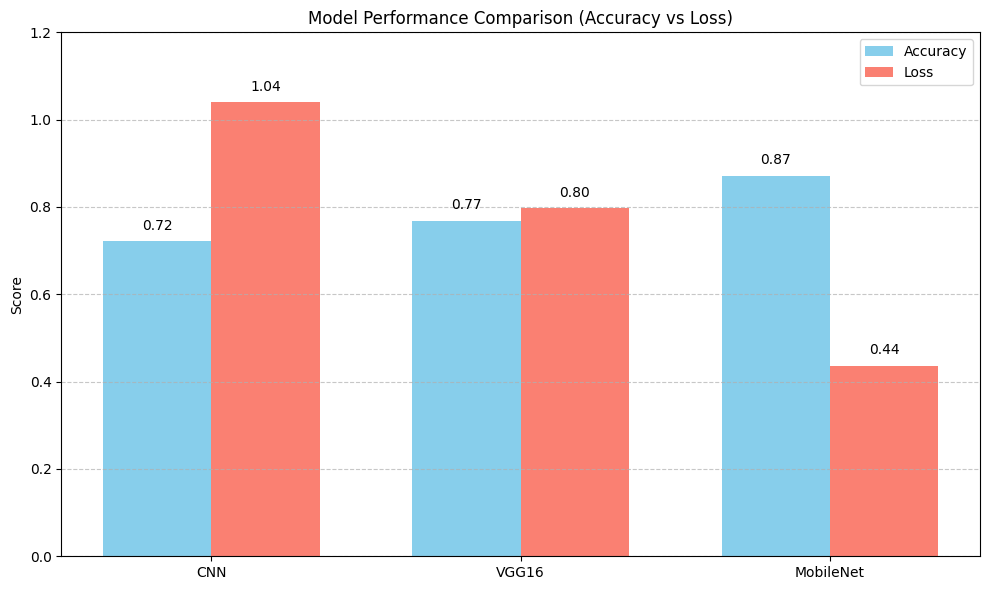

In [4]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import os

# --- Model paths ---
cnn_model_path = '/content/drive/MyDrive/PLANT MODELS COMPARISION/trained_plant_disease_model (3).keras'
vgg16_model_path = '/content/drive/MyDrive/PLANT MODELS COMPARISION/trained_plant_disease_VGG16_model (1).keras'
mobilenet_model_path = '/content/drive/MyDrive/PLANT MODELS COMPARISION/mobilenet_plant_disease_model.keras'

# --- Check model existence ---
for path, name in zip([cnn_model_path, vgg16_model_path, mobilenet_model_path], ['CNN', 'VGG16', 'MobileNet']):
    if os.path.exists(path):
        print(f"{name} Model found ✅")
    else:
        print(f"{name} Model NOT found ❌ - Check the path!")

# --- Load validation dataset for CNN (128x128) ---
valid_dataset_cnn = tf.keras.utils.image_dataset_from_directory(
    "/content/drive/MyDrive/val",
    labels="inferred",
    label_mode="categorical",
    batch_size=32,
    image_size=(128, 128),
    shuffle=False
)
valid_dataset_cnn = valid_dataset_cnn.map(lambda x, y: (tf.keras.layers.Rescaling(1./255)(x), y))

# --- Load validation dataset for VGG16 & MobileNet (224x224) ---
valid_dataset_large = tf.keras.utils.image_dataset_from_directory(
    "/content/drive/MyDrive/val",
    labels="inferred",
    label_mode="categorical",
    batch_size=32,
    image_size=(224, 224),
    shuffle=False
)
valid_dataset_large = valid_dataset_large.map(lambda x, y: (tf.keras.layers.Rescaling(1./255)(x), y))

# --- Load models ---
cnn_model = tf.keras.models.load_model(cnn_model_path)
vgg16_model = tf.keras.models.load_model(vgg16_model_path)
mobilenet_model = tf.keras.models.load_model(mobilenet_model_path)

# --- Evaluate models ---
print("\n🔍 Evaluating CNN...")
val_loss_cnn, val_acc_cnn = cnn_model.evaluate(valid_dataset_cnn, verbose=1)

print("\n🔍 Evaluating VGG16...")
val_loss_vgg, val_acc_vgg = vgg16_model.evaluate(valid_dataset_large, verbose=1)

print("\n🔍 Evaluating MobileNet...")
val_loss_mob, val_acc_mob = mobilenet_model.evaluate(valid_dataset_large, verbose=1)

# --- Print results ---
print("\n📊 Evaluation Results:")
print(f"CNN (128x128)       - Accuracy: {val_acc_cnn:.4f} | Loss: {val_loss_cnn:.4f}")
print(f"VGG16 (224x224)     - Accuracy: {val_acc_vgg:.4f} | Loss: {val_loss_vgg:.4f}")
print(f"MobileNet (224x224) - Accuracy: {val_acc_mob:.4f} | Loss: {val_loss_mob:.4f}")

# --- Prepare data for bar plot ---
models = ['CNN', 'VGG16', 'MobileNet']
accuracies = [val_acc_cnn, val_acc_vgg, val_acc_mob]
losses = [val_loss_cnn, val_loss_vgg, val_loss_mob]

x = np.arange(len(models))
width = 0.35

# --- Plot bar chart ---
plt.figure(figsize=(10, 6))
bars1 = plt.bar(x - width/2, accuracies, width, label='Accuracy', color='skyblue')
bars2 = plt.bar(x + width/2, losses, width, label='Loss', color='salmon')

# Add value labels on bars
for bar in bars1:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2.0, height + 0.02, f'{height:.2f}', ha='center', va='bottom')

for bar in bars2:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2.0, height + 0.02, f'{height:.2f}', ha='center', va='bottom')

plt.ylabel('Score')
plt.title('Model Performance Comparison (Accuracy vs Loss)')
plt.xticks(x, models)
plt.ylim(0, 1.2)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


Found 3770 files belonging to 37 classes.
Found 3770 files belonging to 37 classes.
CNN Class Names: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 583ms/step
Class names in this dataset: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mite

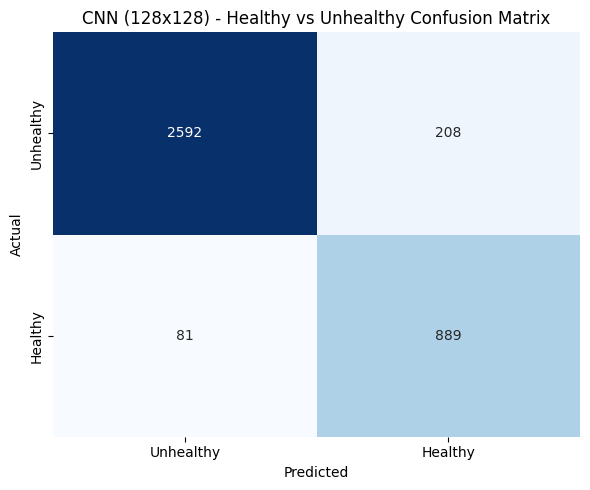

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 845ms/step
Class names in this dataset: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mite

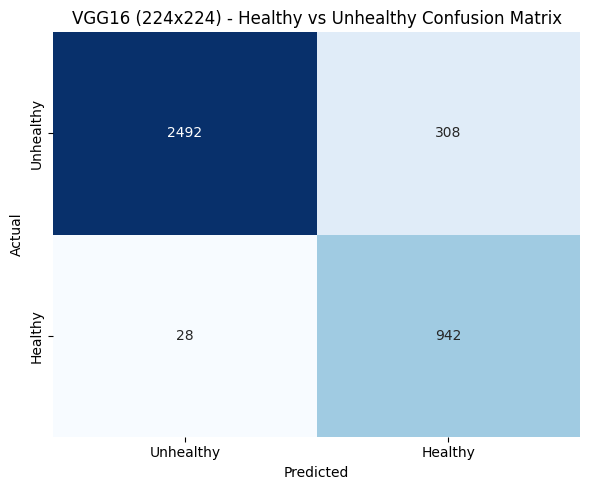

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
Class names in this dataset: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites T

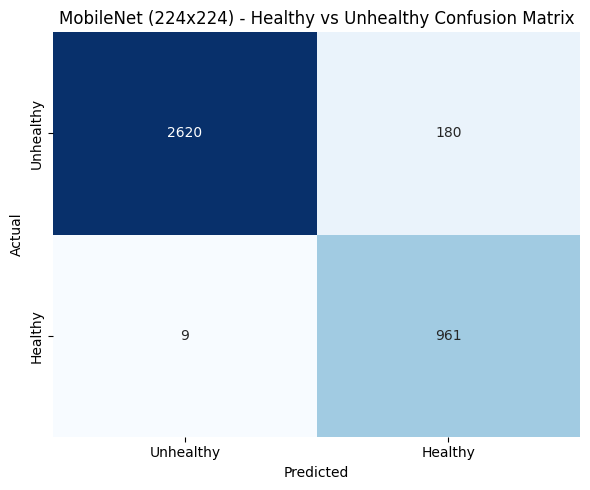


📊 Summary Metrics:
CNN       - Accuracy: 0.9233, Precision: 0.8104, Recall: 0.9165, F1-Score: 0.8602
VGG16     - Accuracy: 0.9109, Precision: 0.7536, Recall: 0.9711, F1-Score: 0.8486
MobileNet - Accuracy: 0.9499, Precision: 0.8422, Recall: 0.9907, F1-Score: 0.9105


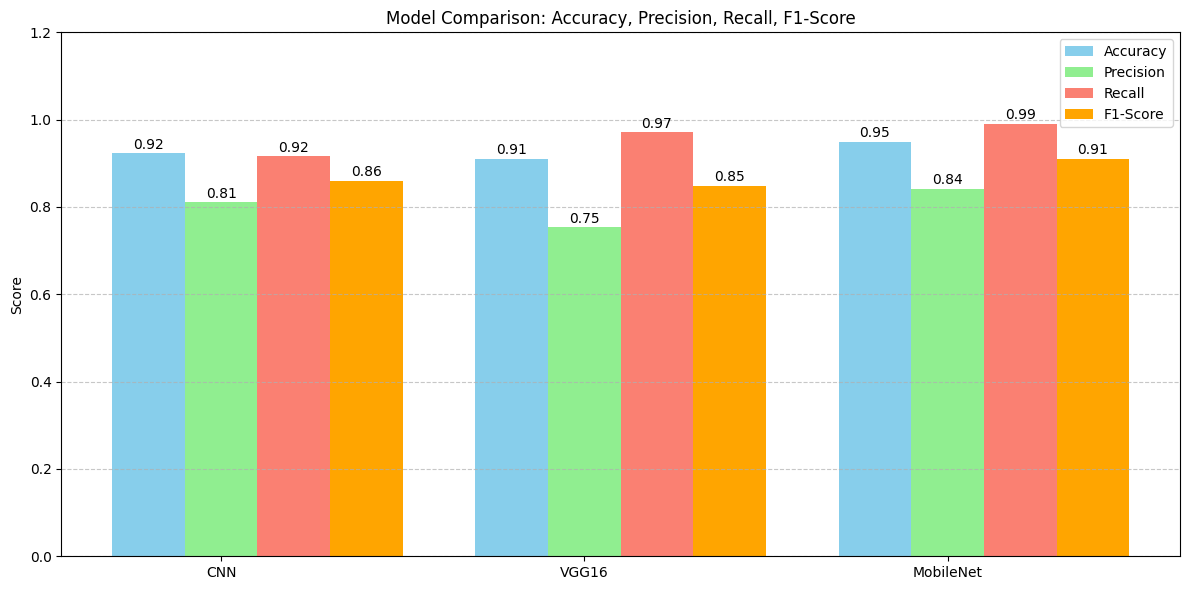

In [17]:
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# --- Load datasets without transformations to access class names ---
valid_dataset_cnn_raw = tf.keras.utils.image_dataset_from_directory(
    "/content/drive/MyDrive/val",
    labels="inferred",
    label_mode="categorical",
    batch_size=32,
    image_size=(128, 128),
    shuffle=False
)

valid_dataset_large_raw = tf.keras.utils.image_dataset_from_directory(
    "/content/drive/MyDrive/val",
    labels="inferred",
    label_mode="categorical",
    batch_size=32,
    image_size=(224, 224),
    shuffle=False
)

# --- Get class names from the raw datasets ---
class_names_cnn = valid_dataset_cnn_raw.class_names
class_names_large = valid_dataset_large_raw.class_names

print("CNN Class Names:", class_names_cnn)
print("VGG16/MobileNet Class Names:", class_names_large)

# --- Apply transformations (Rescaling) after extracting class names ---
valid_dataset_cnn = valid_dataset_cnn_raw.map(lambda x, y: (tf.keras.layers.Rescaling(1./255)(x), y))
valid_dataset_large = valid_dataset_large_raw.map(lambda x, y: (tf.keras.layers.Rescaling(1./255)(x), y))

# --- Helper function to convert class labels to binary (Healthy vs Unhealthy) ---
def to_binary_labels(class_names, labels):
    # Modify these names according to the actual dataset
    print("Class names in this dataset:", class_names)

    # Determine if the class name contains "healthy"
    healthy_class_indices = [i for i, cls in enumerate(class_names) if 'healthy' in cls.lower()]
    unhealthy_class_indices = [i for i, cls in enumerate(class_names) if 'healthy' not in cls.lower()]

    # Return 1 for healthy and 0 for unhealthy
    return [1 if label in healthy_class_indices else 0 for label in labels]

# --- Load models ---
cnn_model_path = '/content/drive/MyDrive/PLANT MODELS COMPARISION/trained_plant_disease_model (3).keras'
vgg16_model_path = '/content/drive/MyDrive/PLANT MODELS COMPARISION/trained_plant_disease_VGG16_model (1).keras'
mobilenet_model_path = '/content/drive/MyDrive/PLANT MODELS COMPARISION/mobilenet_plant_disease_model.keras'

cnn_model = tf.keras.models.load_model(cnn_model_path)
vgg16_model = tf.keras.models.load_model(vgg16_model_path)
mobilenet_model = tf.keras.models.load_model(mobilenet_model_path)

# --- Helper function to evaluate models and compute metrics ---
def evaluate_model(model, dataset, name, class_names):
    y_true = []
    y_pred = []

    # Convert multi-class to binary labels (Healthy vs Unhealthy)
    for images, labels in dataset:
        preds = model.predict(images)
        y_true.extend(to_binary_labels(class_names, np.argmax(labels.numpy(), axis=1)))
        y_pred.extend(to_binary_labels(class_names, np.argmax(preds, axis=1)))

    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    accuracy = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    print(f"\n🔍 Evaluation for {name}:")
    print(classification_report(y_true, y_pred))

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)

    # Plot confusion matrix for Healthy vs Unhealthy
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, xticklabels=["Unhealthy", "Healthy"], yticklabels=["Unhealthy", "Healthy"])
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"{name} - Healthy vs Unhealthy Confusion Matrix")
    plt.tight_layout()
    plt.show()

    return precision, recall, accuracy, f1

# --- Evaluate models ---
precision_cnn, recall_cnn, acc_cnn, f1_cnn = evaluate_model(cnn_model, valid_dataset_cnn, "CNN (128x128)", class_names_cnn)
precision_vgg, recall_vgg, acc_vgg, f1_vgg = evaluate_model(vgg16_model, valid_dataset_large, "VGG16 (224x224)", class_names_large)
precision_mob, recall_mob, acc_mob, f1_mob = evaluate_model(mobilenet_model, valid_dataset_large, "MobileNet (224x224)", class_names_large)

# --- Print results summary ---
print("\n📊 Summary Metrics:")
print(f"CNN       - Accuracy: {acc_cnn:.4f}, Precision: {precision_cnn:.4f}, Recall: {recall_cnn:.4f}, F1-Score: {f1_cnn:.4f}")
print(f"VGG16     - Accuracy: {acc_vgg:.4f}, Precision: {precision_vgg:.4f}, Recall: {recall_vgg:.4f}, F1-Score: {f1_vgg:.4f}")
print(f"MobileNet - Accuracy: {acc_mob:.4f}, Precision: {precision_mob:.4f}, Recall: {recall_mob:.4f}, F1-Score: {f1_mob:.4f}")

# --- Bar Plot ---
models = ['CNN', 'VGG16', 'MobileNet']
accuracies = [acc_cnn, acc_vgg, acc_mob]
precisions = [precision_cnn, precision_vgg, precision_mob]
recalls = [recall_cnn, recall_vgg, recall_mob]
f1_scores = [f1_cnn, f1_vgg, f1_mob]

x = np.arange(len(models))
width = 0.2

plt.figure(figsize=(12, 6))
plt.bar(x - width, accuracies, width, label='Accuracy', color='skyblue')
plt.bar(x, precisions, width, label='Precision', color='lightgreen')
plt.bar(x + width, recalls, width, label='Recall', color='salmon')
plt.bar(x + 2*width, f1_scores, width, label='F1-Score', color='orange')

for i in range(len(models)):
    plt.text(x[i] - width, accuracies[i] + 0.01, f'{accuracies[i]:.2f}', ha='center')
    plt.text(x[i], precisions[i] + 0.01, f'{precisions[i]:.2f}', ha='center')
    plt.text(x[i] + width, recalls[i] + 0.01, f'{recalls[i]:.2f}', ha='center')
    plt.text(x[i] + 2*width, f1_scores[i] + 0.01, f'{f1_scores[i]:.2f}', ha='center')

plt.ylabel('Score')
plt.title('Model Comparison: Accuracy, Precision, Recall, F1-Score')
plt.xticks(x, models)
plt.ylim(0, 1.2)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


Found 3770 files belonging to 37 classes.
Found 3770 files belonging to 37 classes.
CNN Class Names: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_

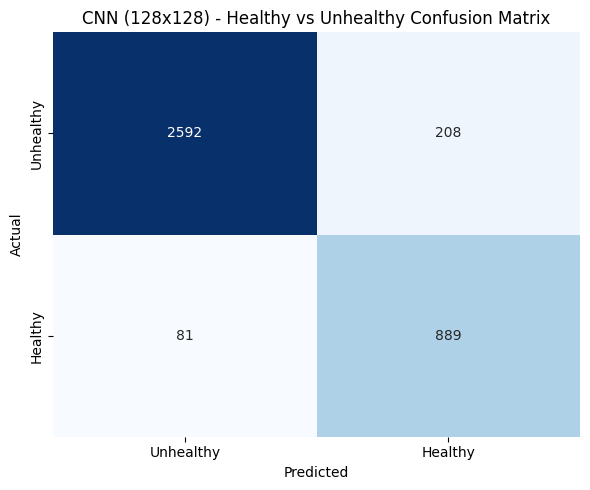

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 813ms/step
Class names in this dataset: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mite

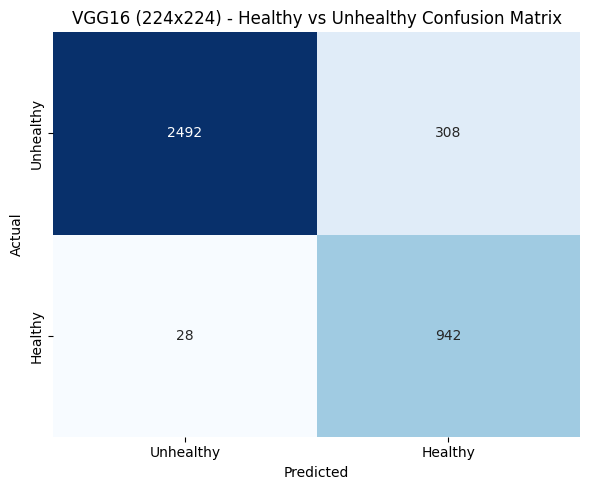

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
Class names in this dataset: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites T

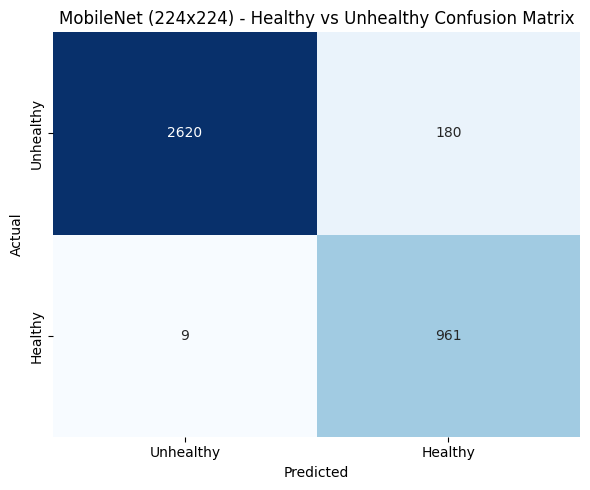

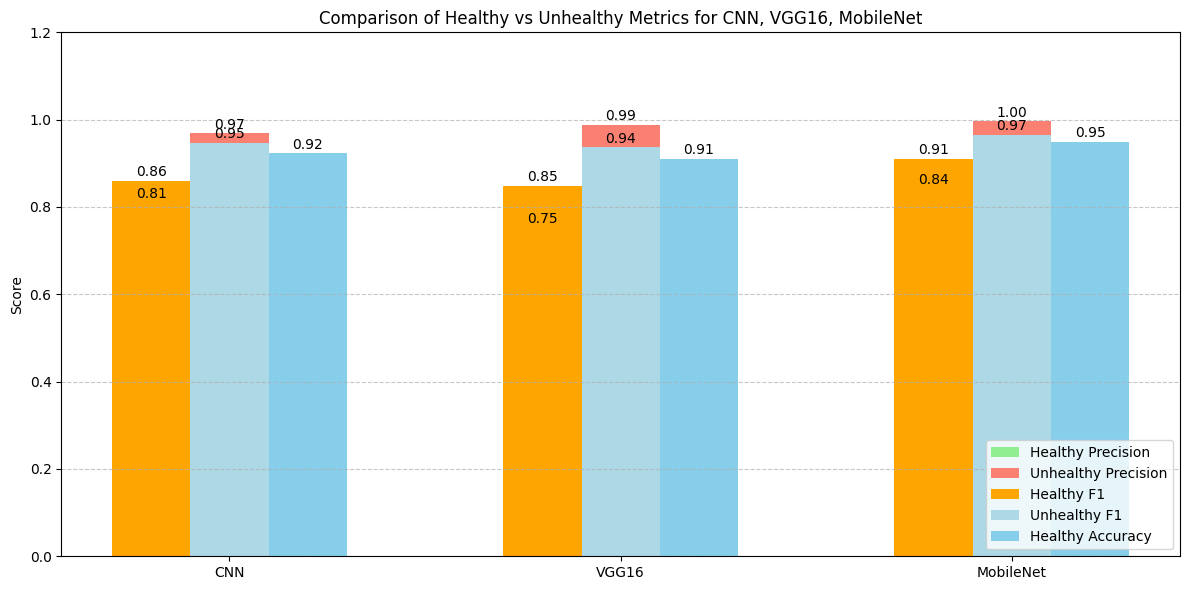

In [20]:
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, accuracy_score, f1_score
import numpy as np

# --- Load datasets without transformations to access class names ---
valid_dataset_cnn_raw = tf.keras.utils.image_dataset_from_directory(
    "/content/drive/MyDrive/val",
    labels="inferred",
    label_mode="categorical",
    batch_size=32,
    image_size=(128, 128),
    shuffle=False
)

valid_dataset_large_raw = tf.keras.utils.image_dataset_from_directory(
    "/content/drive/MyDrive/val",
    labels="inferred",
    label_mode="categorical",
    batch_size=32,
    image_size=(224, 224),
    shuffle=False
)

# --- Get class names from the raw datasets ---
class_names_cnn = valid_dataset_cnn_raw.class_names
class_names_large = valid_dataset_large_raw.class_names

print("CNN Class Names:", class_names_cnn)
print("VGG16/MobileNet Class Names:", class_names_large)

# --- Apply transformations (Rescaling) after extracting class names ---
valid_dataset_cnn = valid_dataset_cnn_raw.map(lambda x, y: (tf.keras.layers.Rescaling(1./255)(x), y))
valid_dataset_large = valid_dataset_large_raw.map(lambda x, y: (tf.keras.layers.Rescaling(1./255)(x), y))

# --- Helper function to convert class labels to binary (Healthy vs Unhealthy) ---
def to_binary_labels(class_names, labels):
    print("Class names in this dataset:", class_names)

    # Determine if the class name contains "healthy"
    healthy_class_indices = [i for i, cls in enumerate(class_names) if 'healthy' in cls.lower()]
    unhealthy_class_indices = [i for i, cls in enumerate(class_names) if 'healthy' not in cls.lower()]

    # Return 1 for healthy and 0 for unhealthy
    return [1 if label in healthy_class_indices else 0 for label in labels]

# --- Load models ---
cnn_model_path = '/content/drive/MyDrive/PLANT MODELS COMPARISION/trained_plant_disease_model (3).keras'
vgg16_model_path = '/content/drive/MyDrive/PLANT MODELS COMPARISION/trained_plant_disease_VGG16_model (1).keras'
mobilenet_model_path = '/content/drive/MyDrive/PLANT MODELS COMPARISION/mobilenet_plant_disease_model.keras'

cnn_model = tf.keras.models.load_model(cnn_model_path)
vgg16_model = tf.keras.models.load_model(vgg16_model_path)
mobilenet_model = tf.keras.models.load_model(mobilenet_model_path)

# --- Helper function to evaluate models and compute metrics ---
def evaluate_model(model, dataset, name, class_names):
    y_true = []
    y_pred = []

    # Convert multi-class to binary labels (Healthy vs Unhealthy)
    for images, labels in dataset:
        preds = model.predict(images)
        y_true.extend(to_binary_labels(class_names, np.argmax(labels.numpy(), axis=1)))
        y_pred.extend(to_binary_labels(class_names, np.argmax(preds, axis=1)))

    # Get precision, recall, accuracy, and F1 for both classes (Healthy and Unhealthy)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    accuracy = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    # Generate classification report
    report = classification_report(y_true, y_pred, target_names=["Unhealthy", "Healthy"], output_dict=True)

    # Extract precision, recall, and f1 for Healthy and Unhealthy
    precision_healthy = report['Healthy']['precision']
    recall_healthy = report['Healthy']['recall']
    f1_healthy = report['Healthy']['f1-score']

    precision_unhealthy = report['Unhealthy']['precision']
    recall_unhealthy = report['Unhealthy']['recall']
    f1_unhealthy = report['Unhealthy']['f1-score']

    print(f"\n🔍 Evaluation for {name}:")
    print(report)

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)

    # Plot confusion matrix for Healthy vs Unhealthy
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, xticklabels=["Unhealthy", "Healthy"], yticklabels=["Unhealthy", "Healthy"])
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"{name} - Healthy vs Unhealthy Confusion Matrix")
    plt.tight_layout()
    plt.show()

    return {
        'precision_healthy': precision_healthy,
        'recall_healthy': recall_healthy,
        'f1_healthy': f1_healthy,
        'precision_unhealthy': precision_unhealthy,
        'recall_unhealthy': recall_unhealthy,
        'f1_unhealthy': f1_unhealthy,
        'accuracy': accuracy,
    }

# --- Evaluate models ---
metrics_cnn = evaluate_model(cnn_model, valid_dataset_cnn, "CNN (128x128)", class_names_cnn)
metrics_vgg = evaluate_model(vgg16_model, valid_dataset_large, "VGG16 (224x224)", class_names_large)
metrics_mob = evaluate_model(mobilenet_model, valid_dataset_large, "MobileNet (224x224)", class_names_large)

# --- Bar Plot to compare Healthy vs Unhealthy metrics for all models ---
models = ['CNN', 'VGG16', 'MobileNet']
healthy_precision = [metrics_cnn['precision_healthy'], metrics_vgg['precision_healthy'], metrics_mob['precision_healthy']]
unhealthy_precision = [metrics_cnn['precision_unhealthy'], metrics_vgg['precision_unhealthy'], metrics_mob['precision_unhealthy']]
healthy_f1 = [metrics_cnn['f1_healthy'], metrics_vgg['f1_healthy'], metrics_mob['f1_healthy']]
unhealthy_f1 = [metrics_cnn['f1_unhealthy'], metrics_vgg['f1_unhealthy'], metrics_mob['f1_unhealthy']]
healthy_accuracy = [metrics_cnn['accuracy'], metrics_vgg['accuracy'], metrics_mob['accuracy']]

x = np.arange(len(models))
width = 0.2  # the width of the bars

plt.figure(figsize=(12, 6))

# Plotting the precision, recall, F1 score, and accuracy
plt.bar(x - width, healthy_precision, width, label='Healthy Precision', color='lightgreen')
plt.bar(x, unhealthy_precision, width, label='Unhealthy Precision', color='salmon')
plt.bar(x - width, healthy_f1, width, label='Healthy F1', color='orange')
plt.bar(x, unhealthy_f1, width, label='Unhealthy F1', color='lightblue')
plt.bar(x + width, healthy_accuracy, width, label='Healthy Accuracy', color='skyblue')

# Annotate with values on top of bars
for i in range(len(models)):
    plt.text(x[i] - width, healthy_precision[i] + 0.01, f'{healthy_precision[i]:.2f}', ha='center')
    plt.text(x[i], unhealthy_precision[i] + 0.01, f'{unhealthy_precision[i]:.2f}', ha='center')
    plt.text(x[i] - width, healthy_f1[i] + 0.01, f'{healthy_f1[i]:.2f}', ha='center')
    plt.text(x[i], unhealthy_f1[i] + 0.01, f'{unhealthy_f1[i]:.2f}', ha='center')
    plt.text(x[i] + width, healthy_accuracy[i] + 0.01, f'{healthy_accuracy[i]:.2f}', ha='center')

plt.ylabel('Score')
plt.title('Comparison of Healthy vs Unhealthy Metrics for CNN, VGG16, MobileNet')
plt.xticks(x, models)
plt.ylim(0, 1.2)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


Found 3770 files belonging to 37 classes.
Found 3770 files belonging to 37 classes.
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 542ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1

<ipython-input-4-a75b0d783cd7>:102: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


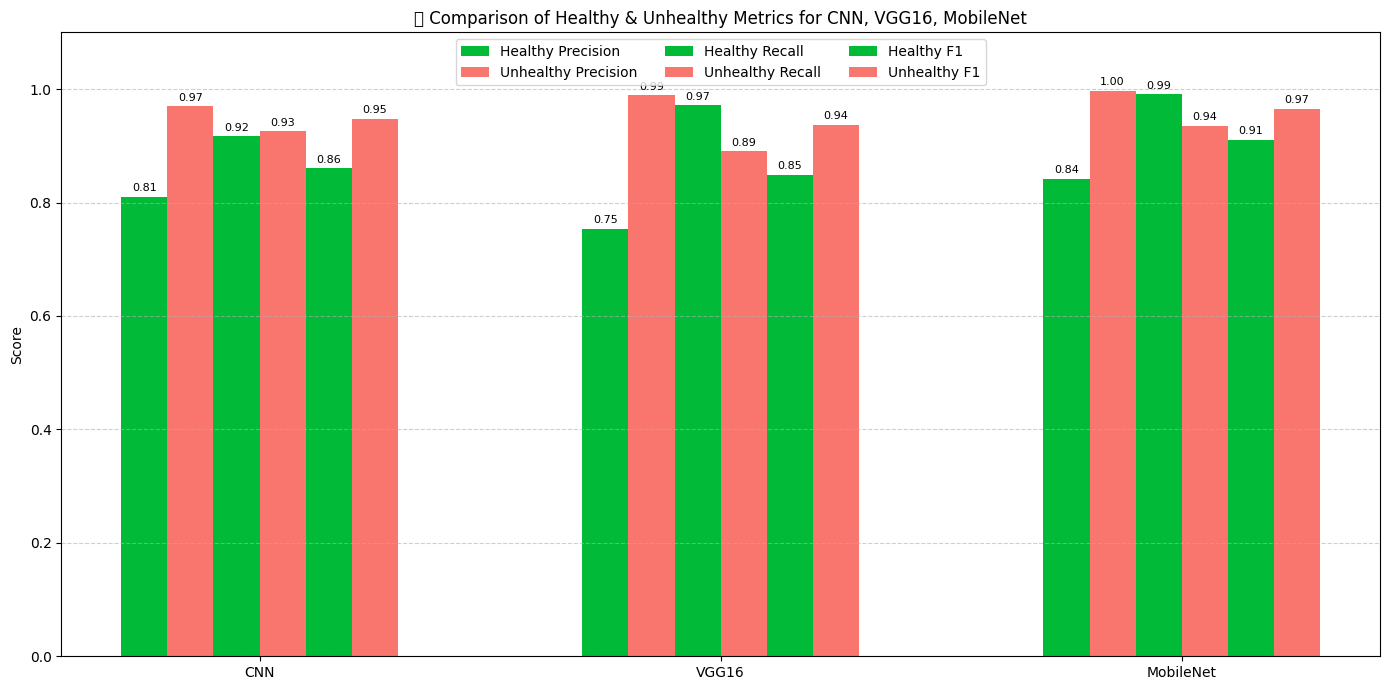

In [4]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# --- Load datasets ---
valid_dataset_cnn_raw = tf.keras.utils.image_dataset_from_directory(
    "/content/drive/MyDrive/val",
    labels="inferred",
    label_mode="categorical",
    batch_size=32,
    image_size=(128, 128),
    shuffle=False
)

valid_dataset_large_raw = tf.keras.utils.image_dataset_from_directory(
    "/content/drive/MyDrive/val",
    labels="inferred",
    label_mode="categorical",
    batch_size=32,
    image_size=(224, 224),
    shuffle=False
)

class_names_cnn = valid_dataset_cnn_raw.class_names
class_names_large = valid_dataset_large_raw.class_names

valid_dataset_cnn = valid_dataset_cnn_raw.map(lambda x, y: (tf.keras.layers.Rescaling(1./255)(x), y))
valid_dataset_large = valid_dataset_large_raw.map(lambda x, y: (tf.keras.layers.Rescaling(1./255)(x), y))

# --- Label conversion ---
def to_binary_labels(class_names, labels):
    healthy_indices = [i for i, name in enumerate(class_names) if 'healthy' in name.lower()]
    return [1 if label in healthy_indices else 0 for label in labels]

# --- Load models ---
cnn_model = tf.keras.models.load_model('/content/drive/MyDrive/PLANT MODELS COMPARISION/trained_plant_disease_model (3).keras')
vgg16_model = tf.keras.models.load_model('/content/drive/MyDrive/PLANT MODELS COMPARISION/trained_plant_disease_VGG16_model (1).keras')
mobilenet_model = tf.keras.models.load_model('/content/drive/MyDrive/PLANT MODELS COMPARISION/mobilenet_plant_disease_model.keras')

# --- Evaluation function ---
def evaluate_model(model, dataset, model_name, class_names):
    y_true, y_pred = [], []

    for images, labels in dataset:
        preds = model.predict(images)
        y_true.extend(to_binary_labels(class_names, np.argmax(labels.numpy(), axis=1)))
        y_pred.extend(to_binary_labels(class_names, np.argmax(preds, axis=1)))

    report = classification_report(y_true, y_pred, target_names=["Unhealthy", "Healthy"], output_dict=True)
    cm = confusion_matrix(y_true, y_pred)

    print(f"\n📊 {model_name}")
    print(classification_report(y_true, y_pred, target_names=["Unhealthy", "Healthy"]))

    return {
        'Healthy': {
            'precision': report['Healthy']['precision'],
            'recall': report['Healthy']['recall'],
            'f1': report['Healthy']['f1-score'],
        },
        'Unhealthy': {
            'precision': report['Unhealthy']['precision'],
            'recall': report['Unhealthy']['recall'],
            'f1': report['Unhealthy']['f1-score'],
        }
    }

# --- Evaluate all models ---
metrics = {
    "CNN": evaluate_model(cnn_model, valid_dataset_cnn, "CNN (128x128)", class_names_cnn),
    "VGG16": evaluate_model(vgg16_model, valid_dataset_large, "VGG16 (224x224)", class_names_large),
    "MobileNet": evaluate_model(mobilenet_model, valid_dataset_large, "MobileNet (224x224)", class_names_large)
}

# --- Create single grouped bar chart ---
models = list(metrics.keys())
categories = ['precision', 'recall', 'f1']
labels = ['Healthy', 'Unhealthy']
bar_labels = [f"{label} {metric.capitalize()}" for metric in categories for label in labels]

x = np.arange(len(models))
width = 0.1

plt.figure(figsize=(14, 7))
colors = ['#00ba38', '#f8766d', '#00ba38', '#f8766d', '#00ba38', '#f8766d']  # Alternating green/red

# Loop through all metrics for healthy/unhealthy and plot
for i, (metric, label) in enumerate([(m, l) for m in categories for l in labels]):
    values = [metrics[model][label][metric] for model in models]
    plt.bar(x + (i - 2.5)*width, values, width, label=f"{label} {metric.capitalize()}", color=colors[i])
    for j in range(len(models)):
        plt.text(x[j] + (i - 2.5)*width, values[j] + 0.01, f'{values[j]:.2f}', ha='center', fontsize=8)

plt.xticks(x, models)
plt.ylim(0, 1.1)
plt.ylabel("Score")
plt.title("📊 Comparison of Healthy & Unhealthy Metrics for CNN, VGG16, MobileNet")
plt.legend(loc="upper center", ncol=3)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


Found 3770 files belonging to 37 classes.
Found 3770 files belonging to 37 classes.
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 565ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1

<ipython-input-14-42149b0de461>:152: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


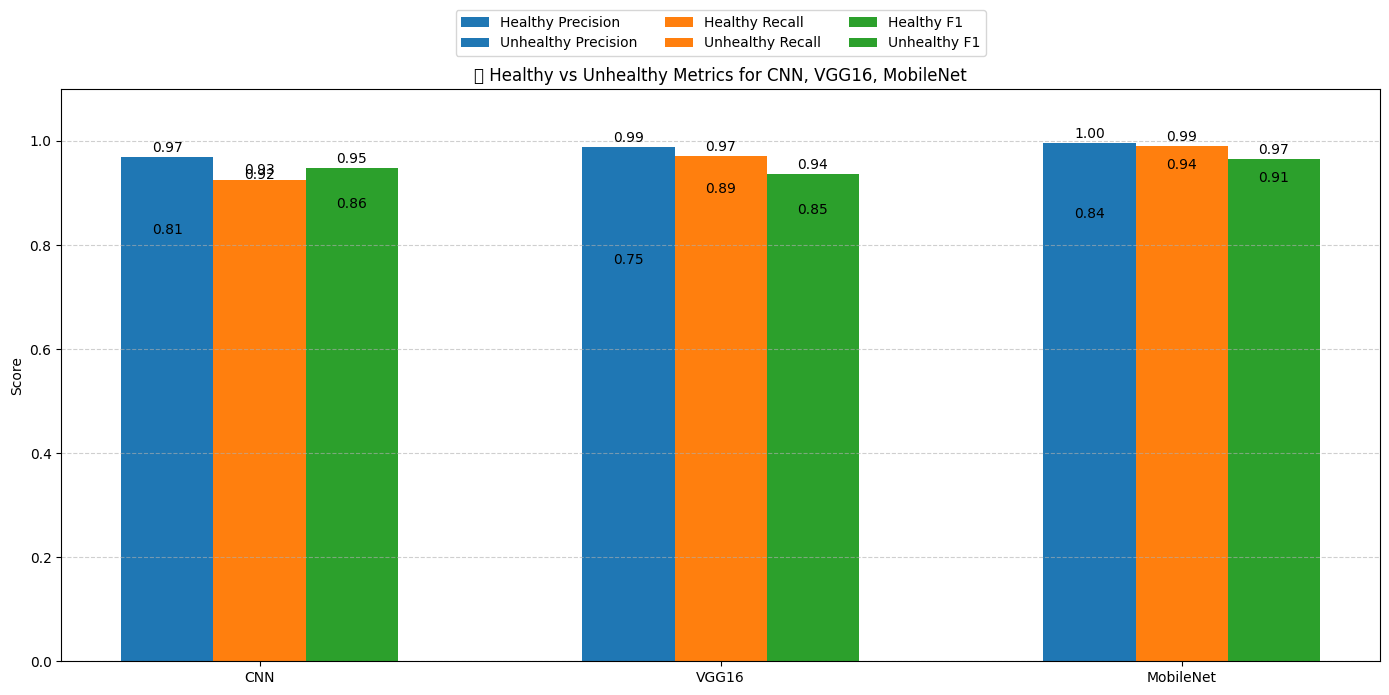

In [14]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# --- Load datasets ---
valid_dataset_cnn_raw = tf.keras.utils.image_dataset_from_directory(
    "/content/drive/MyDrive/val",
    labels="inferred",
    label_mode="categorical",
    batch_size=32,
    image_size=(128, 128),
    shuffle=False
)

valid_dataset_large_raw = tf.keras.utils.image_dataset_from_directory(
    "/content/drive/MyDrive/val",
    labels="inferred",
    label_mode="categorical",
    batch_size=32,
    image_size=(224, 224),
    shuffle=False
)

class_names_cnn = valid_dataset_cnn_raw.class_names
class_names_large = valid_dataset_large_raw.class_names

valid_dataset_cnn = valid_dataset_cnn_raw.map(lambda x, y: (tf.keras.layers.Rescaling(1./255)(x), y))
valid_dataset_large = valid_dataset_large_raw.map(lambda x, y: (tf.keras.layers.Rescaling(1./255)(x), y))

# --- Label conversion ---
def to_binary_labels(class_names, labels):
    healthy_indices = [i for i, name in enumerate(class_names) if 'healthy' in name.lower()]
    return [1 if label in healthy_indices else 0 for label in labels]

# --- Load models ---
cnn_model = tf.keras.models.load_model('/content/drive/MyDrive/PLANT MODELS COMPARISION/trained_plant_disease_model (3).keras')
vgg16_model = tf.keras.models.load_model('/content/drive/MyDrive/PLANT MODELS COMPARISION/trained_plant_disease_VGG16_model (1).keras')
mobilenet_model = tf.keras.models.load_model('/content/drive/MyDrive/PLANT MODELS COMPARISION/mobilenet_plant_disease_model.keras')

# --- Evaluation function ---
def evaluate_model(model, dataset, model_name, class_names):
    y_true, y_pred = [], []

    for images, labels in dataset:
        preds = model.predict(images)
        y_true.extend(to_binary_labels(class_names, np.argmax(labels.numpy(), axis=1)))
        y_pred.extend(to_binary_labels(class_names, np.argmax(preds, axis=1)))

    report = classification_report(y_true, y_pred, target_names=["Unhealthy", "Healthy"], output_dict=True)
    cm = confusion_matrix(y_true, y_pred)

    print(f"\n📊 {model_name}")
    print(classification_report(y_true, y_pred, target_names=["Unhealthy", "Healthy"]))

    return {
        'Healthy': {
            'precision': report['Healthy']['precision'],
            'recall': report['Healthy']['recall'],
            'f1': report['Healthy']['f1-score'],
        },
        'Unhealthy': {
            'precision': report['Unhealthy']['precision'],
            'recall': report['Unhealthy']['recall'],
            'f1': report['Unhealthy']['f1-score'],
        }
    }

# --- Evaluate all models ---
metrics = {
    "CNN": evaluate_model(cnn_model, valid_dataset_cnn, "CNN (128x128)", class_names_cnn),
    "VGG16": evaluate_model(vgg16_model, valid_dataset_large, "VGG16 (224x224)", class_names_large),
    "MobileNet": evaluate_model(mobilenet_model, valid_dataset_large, "MobileNet (224x224)", class_names_large)
}

# # --- Create grouped bar chart ---
# models = list(metrics.keys())
# metric_types = ['precision', 'recall', 'f1']
# categories = ['Healthy', 'Unhealthy']
# x = np.arange(len(models))
# bar_width = 0.2

# plt.figure(figsize=(14, 7))
# colors = ['#1f77b4', '#ff7f0e', '#2ca02c']  # One color per metric

# # Plot bars
# for i, metric in enumerate(metric_types):
#     for j, category in enumerate(categories):
#         offset = (i * 2 + j - 3) * bar_width / 2
#         values = [metrics[model][category][metric] for model in models]
#         positions = x + offset
#         label = f"{category} {metric.capitalize()}"
#         alpha = 1.0 if category == 'Healthy' else 0.6
#         plt.bar(positions, values, bar_width, label=label, color=colors[i], alpha=alpha)

#         # Annotate
#         for pos, val in zip(positions, values):
#             plt.text(pos, val + 0.01, f"{val:.2f}", ha='center', fontsize=8)

# # Formatting
# plt.xticks(x, models)
# plt.ylim(0, 1.1)
# plt.ylabel("Score")
# plt.title("📊 Healthy vs Unhealthy Metrics for CNN, VGG16, MobileNet")
# plt.legend(loc="upper center", bbox_to_anchor=(0.5, 1.15), ncol=3)
# plt.grid(axis='y', linestyle='--', alpha=0.6)
# plt.tight_layout()
# plt.show()

import numpy as np
import matplotlib.pyplot as plt

# --- Corrected Grouped Bar Chart ---
models = list(metrics.keys())
metric_types = ['precision', 'recall', 'f1']
categories = ['Healthy', 'Unhealthy']

x = np.arange(len(models))  # Position for the models
bar_width = 0.2  # Width of each bar

# Create a figure and axis for the plot
plt.figure(figsize=(14, 7))

# Colors for each metric
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']  # One color per metric

# Plot bars for each metric and category
for i, metric in enumerate(metric_types):
    for j, category in enumerate(categories):
        # Compute positions for the bars
        positions = x + (i - 1) * bar_width  # Shift bars by their metric index
        values = [metrics[model][category][metric] for model in models]
        label = f"{category} {metric.capitalize()}"

        # Plot the bars
        plt.bar(positions, values, bar_width, label=label, color=colors[i])

        # Annotate bars with values
        for pos, val in zip(positions, values):
            plt.text(pos, val + 0.01, f"{val:.2f}", ha='center', fontsize=10)

# Formatting for the plot
plt.xticks(x, models)  # Set the x-ticks to the model names
plt.ylim(0, 1.1)  # Set the y-axis limits to ensure bars don't touch the top
plt.ylabel("Score")
plt.title("📊 Healthy vs Unhealthy Metrics for CNN, VGG16, MobileNet")
plt.legend(loc="upper center", bbox_to_anchor=(0.5, 1.15), ncol=3)
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Adjust layout to make sure everything fits well
plt.tight_layout()

# Show the plot
plt.show()



Found 3770 files belonging to 37 classes.
Found 3770 files belonging to 37 classes.
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 573ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1

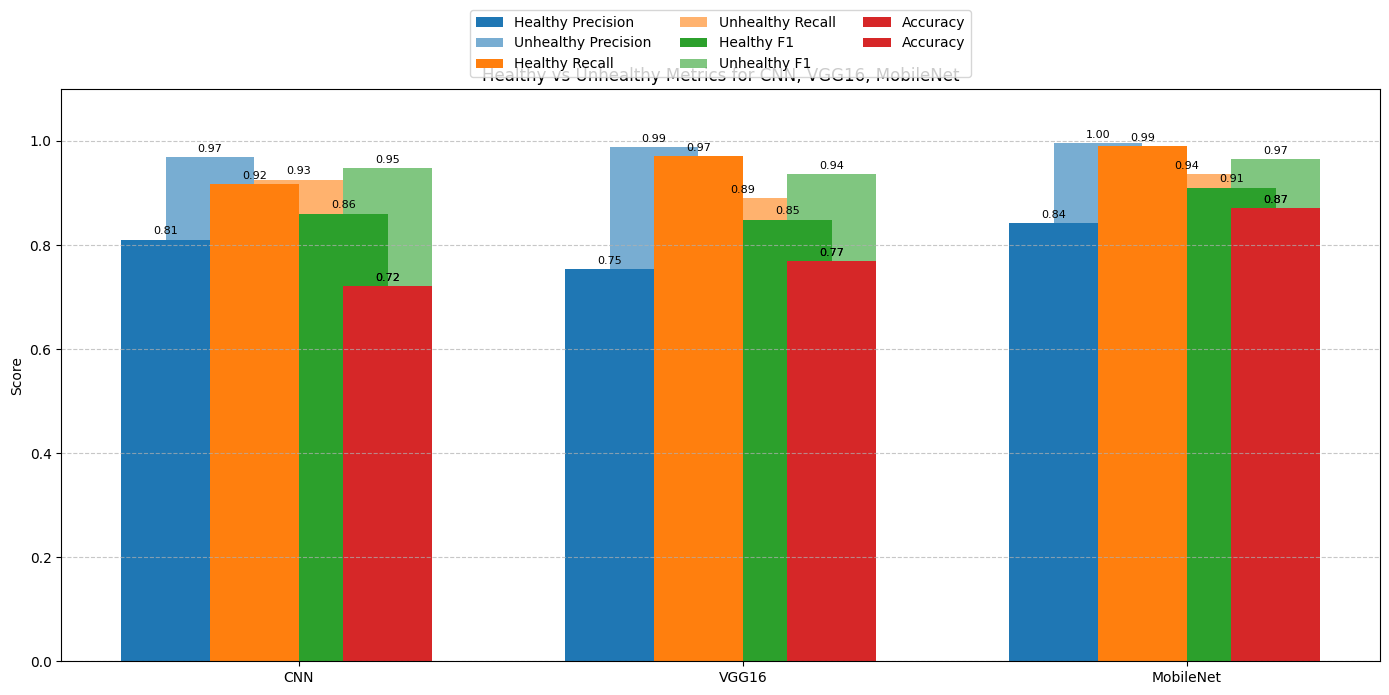

In [17]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

# --- Load datasets ---
valid_dataset_cnn_raw = tf.keras.utils.image_dataset_from_directory(
    "/content/drive/MyDrive/val",
    labels="inferred",
    label_mode="categorical",
    batch_size=32,
    image_size=(128, 128),
    shuffle=False
)

valid_dataset_large_raw = tf.keras.utils.image_dataset_from_directory(
    "/content/drive/MyDrive/val",
    labels="inferred",
    label_mode="categorical",
    batch_size=32,
    image_size=(224, 224),
    shuffle=False
)

class_names_cnn = valid_dataset_cnn_raw.class_names
class_names_large = valid_dataset_large_raw.class_names

# Apply rescaling transformations
valid_dataset_cnn = valid_dataset_cnn_raw.map(lambda x, y: (tf.keras.layers.Rescaling(1./255)(x), y))
valid_dataset_large = valid_dataset_large_raw.map(lambda x, y: (tf.keras.layers.Rescaling(1./255)(x), y))

# --- Label conversion to binary (Healthy vs Unhealthy) ---
def to_binary_labels(class_names, labels):
    healthy_indices = [i for i, name in enumerate(class_names) if 'healthy' in name.lower()]
    return [1 if label in healthy_indices else 0 for label in labels]

# --- Load models ---
cnn_model = tf.keras.models.load_model('/content/drive/MyDrive/PLANT MODELS COMPARISION/trained_plant_disease_model (3).keras')
vgg16_model = tf.keras.models.load_model('/content/drive/MyDrive/PLANT MODELS COMPARISION/trained_plant_disease_VGG16_model (1).keras')
mobilenet_model = tf.keras.models.load_model('/content/drive/MyDrive/PLANT MODELS COMPARISION/mobilenet_plant_disease_model.keras')

# --- Evaluation function ---
def evaluate_model(model, dataset, model_name, class_names):
    y_true, y_pred = [], []
    total = 0
    correct = 0

    for images, labels in dataset:
        preds = model.predict(images)
        y_true.extend(to_binary_labels(class_names, np.argmax(labels.numpy(), axis=1)))
        y_pred.extend(to_binary_labels(class_names, np.argmax(preds, axis=1)))

        # Calculate accuracy
        total += labels.shape[0]
        correct += np.sum(np.argmax(labels.numpy(), axis=1) == np.argmax(preds, axis=1))

    report = classification_report(y_true, y_pred, target_names=["Unhealthy", "Healthy"], output_dict=True)
    accuracy = correct / total  # Calculate accuracy

    print(f"\n📊 {model_name}")
    print(classification_report(y_true, y_pred, target_names=["Unhealthy", "Healthy"]))

    return {
        'Healthy': {
            'precision': report['Healthy']['precision'],
            'recall': report['Healthy']['recall'],
            'f1': report['Healthy']['f1-score'],
        },
        'Unhealthy': {
            'precision': report['Unhealthy']['precision'],
            'recall': report['Unhealthy']['recall'],
            'f1': report['Unhealthy']['f1-score'],
        },
        'accuracy': accuracy  # Add accuracy
    }

# --- Evaluate all models ---
metrics = {
    "CNN": evaluate_model(cnn_model, valid_dataset_cnn, "CNN (128x128)", class_names_cnn),
    "VGG16": evaluate_model(vgg16_model, valid_dataset_large, "VGG16 (224x224)", class_names_large),
    "MobileNet": evaluate_model(mobilenet_model, valid_dataset_large, "MobileNet (224x224)", class_names_large)
}

# --- Create grouped bar chart ---
models = list(metrics.keys())
metric_types = ['precision', 'recall', 'f1', 'accuracy']  # Include accuracy
categories = ['Healthy', 'Unhealthy']
x = np.arange(len(models))
bar_width = 0.2  # Width of each bar

plt.figure(figsize=(14, 7))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']  # One color per metric (add color for accuracy)

# Plot bars
for i, metric in enumerate(metric_types):
    for j, category in enumerate(categories):
        if metric != 'accuracy':  # Plot precision, recall, F1 score
            offset = (i * 2 + j - 3) * bar_width / 2
            values = [metrics[model][category][metric] for model in models]
        else:  # Plot accuracy
            offset = (i - 2) * bar_width  # Accuracy doesn't have a category (Healthy/Unhealthy)
            values = [metrics[model]['accuracy'] for model in models]

        positions = x + offset
        label = f"{category} {metric.capitalize()}" if metric != 'accuracy' else f"Accuracy"
        alpha = 1.0 if category == 'Healthy' or metric == 'accuracy' else 0.6
        plt.bar(positions, values, bar_width, label=label, color=colors[i], alpha=alpha)

        # Annotate
        for pos, val in zip(positions, values):
            plt.text(pos, val + 0.01, f"{val:.2f}", ha='center', fontsize=8)

# Formatting
plt.xticks(x, models)
plt.ylim(0, 1.1)  # Set y-axis limits for clarity
plt.ylabel('Score')
plt.title('Healthy vs Unhealthy Metrics for CNN, VGG16, MobileNet')
plt.legend(loc="upper center", bbox_to_anchor=(0.5, 1.15), ncol=3)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


Found 3770 files belonging to 37 classes.
Found 3770 files belonging to 37 classes.
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 539ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1

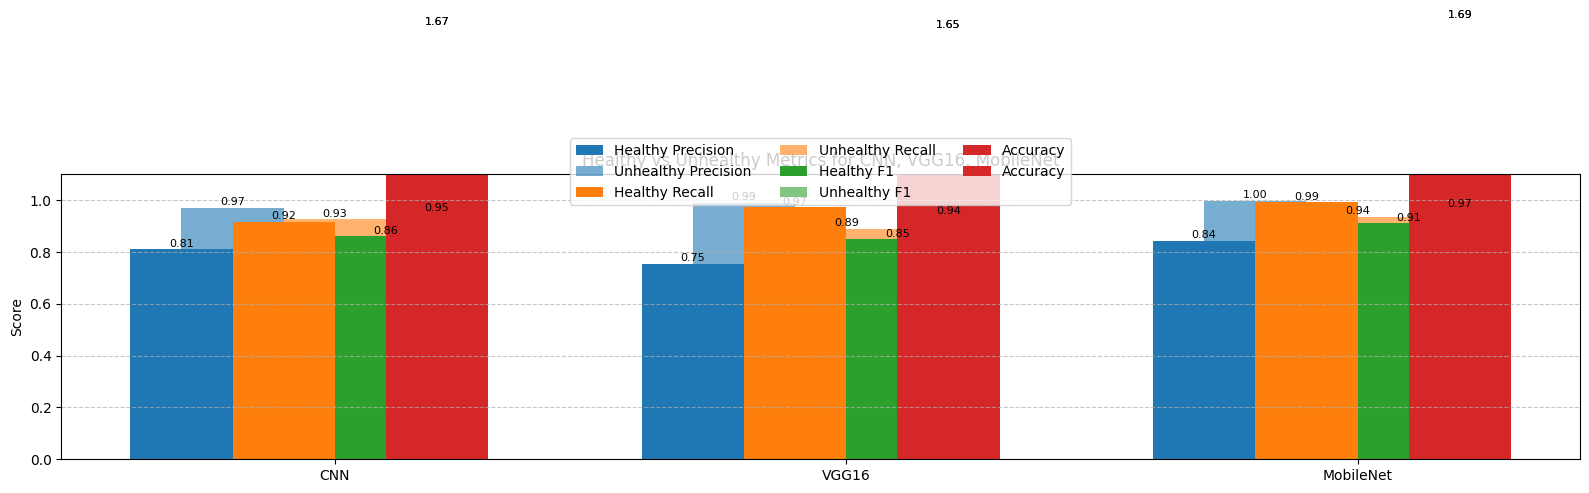

In [25]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

# --- Load datasets ---
valid_dataset_cnn_raw = tf.keras.utils.image_dataset_from_directory(
    "/content/drive/MyDrive/val",
    labels="inferred",
    label_mode="categorical",
    batch_size=32,
    image_size=(128, 128),
    shuffle=False
)

valid_dataset_large_raw = tf.keras.utils.image_dataset_from_directory(
    "/content/drive/MyDrive/val",
    labels="inferred",
    label_mode="categorical",
    batch_size=32,
    image_size=(224, 224),
    shuffle=False
)

class_names_cnn = valid_dataset_cnn_raw.class_names
class_names_large = valid_dataset_large_raw.class_names

# Apply rescaling transformations
valid_dataset_cnn = valid_dataset_cnn_raw.map(lambda x, y: (tf.keras.layers.Rescaling(1./255)(x), y))
valid_dataset_large = valid_dataset_large_raw.map(lambda x, y: (tf.keras.layers.Rescaling(1./255)(x), y))

# --- Label conversion to binary (Healthy vs Unhealthy) ---
def to_binary_labels(class_names, labels):
    healthy_indices = [i for i, name in enumerate(class_names) if 'healthy' in name.lower()]
    return [1 if label in healthy_indices else 0 for label in labels]

# --- Load models ---
cnn_model = tf.keras.models.load_model('/content/drive/MyDrive/PLANT MODELS COMPARISION/trained_plant_disease_model (3).keras')
vgg16_model = tf.keras.models.load_model('/content/drive/MyDrive/PLANT MODELS COMPARISION/trained_plant_disease_VGG16_model (1).keras')
mobilenet_model = tf.keras.models.load_model('/content/drive/MyDrive/PLANT MODELS COMPARISION/mobilenet_plant_disease_model.keras')

# --- Evaluation function ---
def evaluate_model(model, dataset, model_name, class_names):
    y_true, y_pred = [], []
    correct_healthy = 0
    correct_unhealthy = 0
    total = 0

    for images, labels in dataset:
        preds = model.predict(images)
        true_labels = to_binary_labels(class_names, np.argmax(labels.numpy(), axis=1))
        predicted_labels = to_binary_labels(class_names, np.argmax(preds, axis=1))

        y_true.extend(true_labels)
        y_pred.extend(predicted_labels)

        # Calculate correct predictions for each class
        correct_healthy += np.sum(np.array(true_labels) == np.array(predicted_labels) & (np.array(true_labels) == 1))
        correct_unhealthy += np.sum(np.array(true_labels) == np.array(predicted_labels) & (np.array(true_labels) == 0))

        total += len(labels)

    # Calculate Accuracy based on Healthy and Unhealthy classes
    accuracy = (correct_healthy + correct_unhealthy) / total

    # Classification report
    report = classification_report(y_true, y_pred, target_names=["Unhealthy", "Healthy"], output_dict=True)

    print(f"\n {model_name}")
    print(classification_report(y_true, y_pred, target_names=["Unhealthy", "Healthy"]))

    return {
        'Healthy': {
            'precision': report['Healthy']['precision'],
            'recall': report['Healthy']['recall'],
            'f1': report['Healthy']['f1-score'],
        },
        'Unhealthy': {
            'precision': report['Unhealthy']['precision'],
            'recall': report['Unhealthy']['recall'],
            'f1': report['Unhealthy']['f1-score'],
        },
        'accuracy': accuracy  # Return accuracy
    }

# --- Evaluate all models ---
metrics = {
    "CNN": evaluate_model(cnn_model, valid_dataset_cnn, "CNN (128x128)", class_names_cnn),
    "VGG16": evaluate_model(vgg16_model, valid_dataset_large, "VGG16 (224x224)", class_names_large),
    "MobileNet": evaluate_model(mobilenet_model, valid_dataset_large, "MobileNet (224x224)", class_names_large)
}

# --- Create grouped bar chart ---
models = list(metrics.keys())
metric_types = ['precision', 'recall', 'f1', 'accuracy']  # Include accuracy
categories = ['Healthy', 'Unhealthy']
x = np.arange(len(models))
bar_width = 0.2  # Width of each bar

plt.figure(figsize=(14, 7))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']  # One color per metric (add color for accuracy)

# Plot bars
for i, metric in enumerate(metric_types):
    for j, category in enumerate(categories):
        if metric != 'accuracy':  # Plot precision, recall, F1 score
            offset = (i * 2 + j - 3) * bar_width / 2
            values = [metrics[model][category][metric] for model in models]
        else:  # Plot accuracy
            offset = (i - 2) * bar_width  # Accuracy doesn't have a category (Healthy/Unhealthy)
            values = [metrics[model]['accuracy'] for model in models]

        positions = x + offset
        label = f"{category} {metric.capitalize()}" if metric != 'accuracy' else f"Accuracy"
        alpha = 1.0 if category == 'Healthy' or metric == 'accuracy' else 0.6
        plt.bar(positions, values, bar_width, label=label, color=colors[i], alpha=alpha)

        # Annotate
        for pos, val in zip(positions, values):
            plt.text(pos, val + 0.01, f"{val:.2f}", ha='center', fontsize=8)

# Formatting
plt.xticks(x, models)
plt.ylim(0, 1.1)  # Set y-axis limits for clarity
plt.ylabel('Score')
plt.title('Healthy vs Unhealthy Metrics for CNN, VGG16, MobileNet')
plt.legend(loc="upper center", bbox_to_anchor=(0.5, 1.15), ncol=3)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━

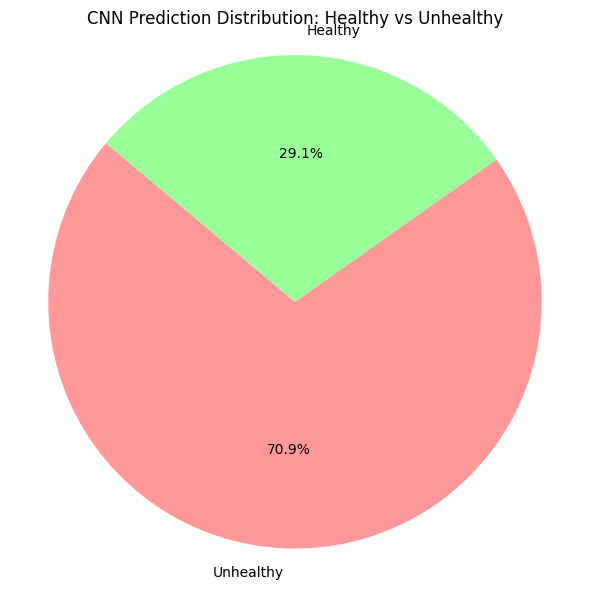

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 240ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

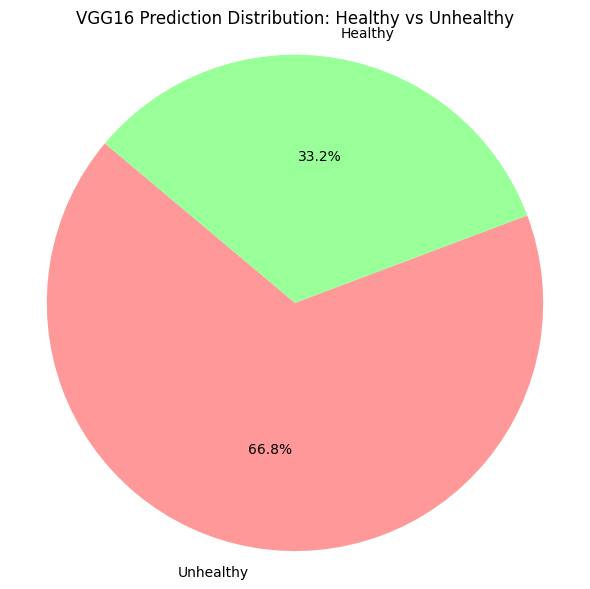

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━

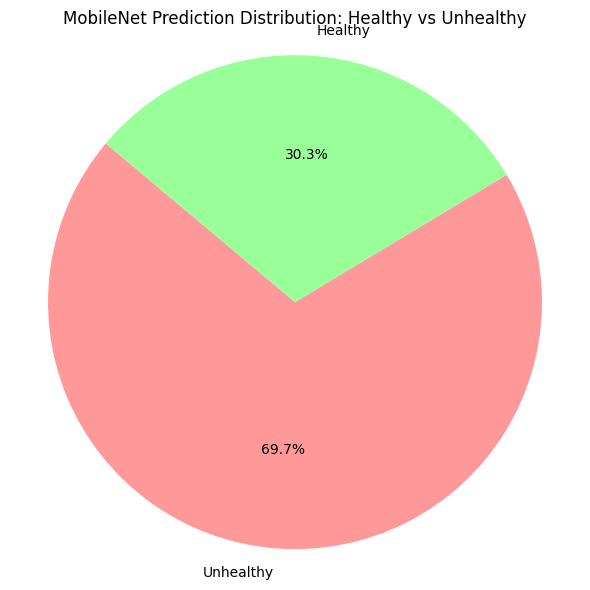

In [28]:
# --- Function to generate pie chart for predicted distributions ---
def plot_prediction_distribution(model, dataset, class_names, model_name):
    y_pred_binary = []
    for images, _ in dataset:
        preds = model.predict(images)
        y_pred_binary.extend(to_binary_labels(class_names, np.argmax(preds, axis=1)))

    # Count predictions for each class
    labels_pie = ["Unhealthy", "Healthy"]
    counts = np.bincount(y_pred_binary)

    # Plot pie chart
    plt.figure(figsize=(6, 6))
    plt.pie(counts, labels=labels_pie, autopct='%1.1f%%', startangle=140, colors=['#FF9999', '#99FF99'])
    plt.title(f"{model_name} Prediction Distribution: Healthy vs Unhealthy")
    plt.axis('equal')  # Circle shape
    plt.tight_layout()
    plt.show()

# --- Generate pie charts for all models ---
plot_prediction_distribution(cnn_model, valid_dataset_cnn, class_names_cnn, "CNN")
plot_prediction_distribution(vgg16_model, valid_dataset_large, class_names_large, "VGG16")
plot_prediction_distribution(mobilenet_model, valid_dataset_large, class_names_large, "MobileNet")
